## 1. Data
Run once; rerun from Settings when changing strategies.

In [1]:
from io import StringIO
import pandas as pd
import matplotlib.pyplot as plt
from crypto_trader.data import fetch_hourly

data = fetch_hourly(period="1y")
frames = {s: pd.read_json(StringIO(raw), orient="table") for s, raw in data.items()}

In [2]:
frames.keys()

dict_keys(['BTC-USD', 'ETH-USD', 'SOL-USD', 'HYPE32196-USD', 'DOGE-USD'])

## 2. Settings
Tune on train; reserve the final three months for testing.

In [3]:
symbol = "SOL-USD"
sample = "train"  # "train", "test", or "all".
fee = 0.000      # Assumed fee per traded dollar; no slippage.
prices = frames[symbol].sort_index().copy()

## 3. Strategy functions
Return a Series on the price index: 0 = cash, 0.5 = half invested, 1 = fully invested. Return NaN during warm-up. Use only current and earlier prices. Do not shift weights here; the backtest does that.

In [4]:
from crypto_trader.strategies.sma_distance import sma_distance

def volatility_adjusted(prices, window=20, multiplier=3):
    sma = prices["Close"].rolling(window).mean()
    distance = prices["Close"] / sma - 1
    volatility = prices["Close"].pct_change().rolling(window).std()
    weight = distance / (multiplier * volatility.replace(0, float("nan")))
    # Zero volatility means cash; incomplete windows remain NaN.
    return weight.clip(-1, 1).fillna(0).where(volatility.notna() & sma.notna())

def sma_crossover(prices, short=20, long=50):
    short_sma = prices["Close"].rolling(short).mean()
    long_sma = prices["Close"].rolling(long).mean()
    return (short_sma > long_sma).astype(float)  # 1.0 for long, 0.0 for cash.

def sma_threshold(prices, threshold=0.01):
    sma = prices["Close"].rolling(20).mean()
    return ((prices["Close"] - sma) / sma).abs() > threshold

# Copy this function and replace the rule with your own.
def my_strategy(prices):
    return pd.Series(0.0, index=prices.index)  # Placeholder: cash.

## 4. Choose strategies
Add an entry and its parameters here. Strategies share the same evaluation dates after warm-up.

In [5]:
strategies = {
    "Original": sma_distance(prices, window=20, scale=10),
    "Volatility adjusted": volatility_adjusted(prices, window=20, multiplier=3),
    # "My strategy": my_strategy(prices),
    "Buy and hold": pd.Series(1.0, index=prices.index),
    "SMA Crossover": sma_crossover(prices),
    "SMA Threshold": sma_threshold(prices),

}
for name, weights in strategies.items():
    assert isinstance(weights, pd.Series) and weights.index.equals(prices.index), name
    assert weights.dropna().between(-1, 1).all(), f"{name}: weights must be -1 to 1"
positions = pd.DataFrame(strategies)

## 5. Shared backtest
Leave this unchanged when adding strategies. Assumes execution at the signal close. Fees approximate changes in target weights, ignoring weight drift and slippage. Each sample starts in cash with an entry fee; no forced exit.

In [6]:
market_returns = prices["Close"].pct_change()
held = positions.shift(1)  # Previous weight earns the next return.
split = prices.index.max() - pd.DateOffset(months=3)
periods = {"train": prices.index < split, "test": prices.index >= split,
           "all": pd.Series(True, index=prices.index)}
selected = held.notna().all(axis=1) & market_returns.notna() & periods[sample]
held = held.loc[selected]
if held.empty:
    raise ValueError("No rows to test: check the sample and warm-up windows.")
turnover = held.diff().abs()
turnover.iloc[0] = held.iloc[0].abs()  # Initial purchase from cash.
strategy_returns = held.mul(market_returns.loc[selected], axis=0) - fee * turnover
equity = (1 + strategy_returns).cumprod()
# Include the starting $1 before the first scored return.
start = prices.index[prices.index.get_loc(equity.index[0]) - 1]
equity = pd.concat([pd.DataFrame(1.0, index=[start], columns=equity.columns), equity])

## 6. Results
After changing a rule or parameter, rerun Settings and every cell below it.

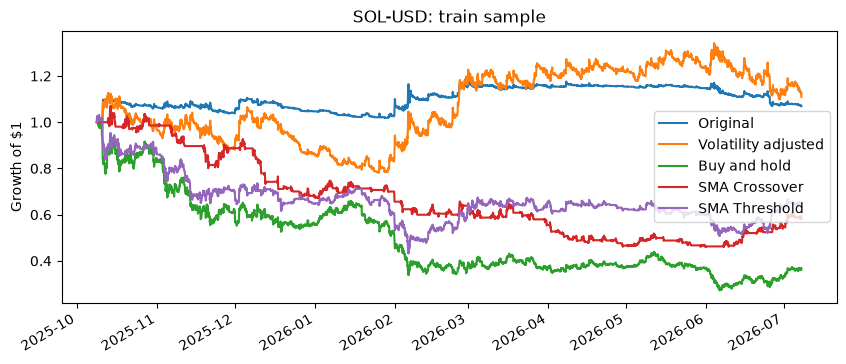

,Total return,Max drawdown,Sharpe ratio
Original,0.069318,0.095543,0.553134
Volatility adjusted,0.1092,0.30653,0.529057
Buy and hold,-0.636591,0.734482,-1.571904
SMA Crossover,-0.416711,0.570687,-1.507178
SMA Threshold,-0.362847,0.581355,-0.825741


In [7]:
equity.plot(figsize=(10, 4), title=f"{symbol}: {sample} sample", ylabel="Growth of $1")
plt.show()
summary = pd.DataFrame({
    "Total return": equity.iloc[-1] - 1,
    "Max drawdown": (1 - equity / equity.cummax()).max(),
    "Sharpe ratio": strategy_returns.mean() / strategy_returns.std() * (365 * 24) ** 0.5,
})
summary